In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [45]:
from utils import (
    clean_nested_columns,
    resize_wafer_maps,
    build_optimized_model,
    plot_training_history,
    add_labels,
    add_bar_labels,
    visualize_original_and_maps,
)

In [46]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [47]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU in uso: {gpus[0].name}")
else:
    print("Nessuna GPU trovata, si usa CPU.")

GPU in uso: /physical_device:GPU:0


In [48]:
df = pd.read_pickle("../project/Dataset.pkl")
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [49]:
df = clean_nested_columns(df)
df.head()

,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


# Wafer shapes

In [50]:
wafer_shapes = df['waferMap'].apply(lambda x: x.shape)
shape_counts = wafer_shapes.value_counts()
print(shape_counts)

print("\nTotal number of different shapes:")
print(len(shape_counts))

waferMap
(25, 27)     18781
(26, 26)     14366
(30, 34)     12400
(29, 26)     11751
(27, 25)     10682
             ...  
(68, 72)         1
(29, 45)         1
(38, 62)         1
(43, 133)        1
(36, 41)         1
Name: count, Length: 346, dtype: int64

Total number of different shapes:
346


In [51]:
# 56x56
X = resize_wafer_maps(df, target_shape=(56, 56))

print(f"\n{X.shape}")

Ridimensionamento delle mappe dei wafer a (56, 56)...


100%|██████████| 172950/172950 [00:10<00:00, 16651.61it/s]



(172950, 56, 56, 1)


# Label encoding

In [52]:
encoder = LabelEncoder()
# Transform the text column into a numeric array (y)
y = encoder.fit_transform(df['failureType'])

print(f"Encoded classes: {encoder.classes_}\n")

Encoded classes: ['center' 'donut' 'edge-loc' 'edge-ring' 'loc' 'near-full' 'none' 'random'
 'scratch']



# Balanced Undersampling (Capping) for ALL classes

In [53]:
MAX_SAMPLES_PER_CLASS = 3000
balanced_indices = []

# Iterate through each unique class found in the dataset
for class_value in np.unique(y):
    # Find all indices belonging to this specific class
    class_indices = np.where(y == class_value)[0]
    
    # If the class has more images than our limit...
    if len(class_indices) > MAX_SAMPLES_PER_CLASS:
        # Randomly sample only MAX_SAMPLES_PER_CLASS
        sampled_indices = np.random.choice(class_indices, size=MAX_SAMPLES_PER_CLASS, replace=False)
    else:
        # If it has fewer (e.g., near-full), keep all of them
        sampled_indices = class_indices
        
    # Add these indices to our global list
    balanced_indices.extend(sampled_indices)

# Convert the list to a NumPy array
balanced_indices = np.array(balanced_indices)

# Randomly shuffle the new dataset to avoid ordered blocks
np.random.shuffle(balanced_indices)

# Creation of final balanced tensors

In [54]:
X_balanced = X[balanced_indices]
y_balanced = y[balanced_indices]

print("\n--- Dataset Ready and Perfectly Balanced ---")
print(f"X_balanced shape: {X_balanced.shape}")
print(f"y_balanced shape: {y_balanced.shape}")

# (Optional) Print the new distribution for confirmation
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nNew class distribution:")
for u, c in zip(unique, counts):
    print(f"{encoder.inverse_transform([u])[0]}: {c}")


--- Dataset Ready and Perfectly Balanced ---
X_balanced shape: (17763, 56, 56, 1)
y_balanced shape: (17763,)

New class distribution:
center: 3000
donut: 555
edge-loc: 3000
edge-ring: 3000
loc: 3000
near-full: 149
none: 3000
random: 866
scratch: 1193


In [55]:
# 1. Pixel Normalization
# Neural networks converge much faster and are more stable with values between 0 and 1
print("Normalizing pixel values...")
X_normalized = X_balanced.astype('float32') / 255.0

# 2. Train, Validation, and Test Split
# We use 'stratify' to ensure the class distribution remains consistent across all sets
# First split: 80% for Training, 20% for Validation/Test combined
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# Second split: Divide the remaining 20% equally into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 3. One-Hot Encoding for Labels
# Convert integer labels (e.g., 2) into probability arrays (e.g., [0, 0, 1, 0, 0, 0, 0, 0, 0])
num_classes = len(np.unique(y_balanced))

y_train_categorical = to_categorical(y_train, num_classes=num_classes)
y_val_categorical = to_categorical(y_val, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

print("\n--- Final Data Shapes ---")
print(f"Training set:   X: {X_train.shape}, y: {y_train_categorical.shape}")
print(f"Validation set: X: {X_val.shape}, y: {y_val_categorical.shape}")
print(f"Test set:       X: {X_test.shape}, y: {y_test_categorical.shape}")

Normalizing pixel values...

--- Final Data Shapes ---
Training set:   X: (14210, 56, 56, 1), y: (14210, 9)
Validation set: X: (1776, 56, 56, 1), y: (1776, 9)
Test set:       X: (1777, 56, 56, 1), y: (1777, 9)


In [56]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_baseline = build_optimized_model(
    use_he=False, 
    use_l2=False, 
    optimizer='adam'
)
model_baseline.summary()

Model: "Flexible_Optimized_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_layer_1 (Conv2D)       (None, 56, 56, 32)        320       
                                                                 
 batch_normalization_45 (Bat  (None, 56, 56, 32)       128       
 chNormalization)                                                
                                                                 
 max_pooling2d_45 (MaxPoolin  (None, 28, 28, 32)       0         
 g2D)                                                            
                                                                 
 conv_layer_2 (Conv2D)       (None, 28, 28, 64)        18496     
                                                                 
 batch_normalization_46 (Bat  (None, 28, 28, 64)       256       
 chNormalization)                                                
                                            

# Training Baseline Model

In [57]:
history_baseline = model_baseline.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        ModelCheckpoint(filepath='baseline.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/50
221/223 [============================>.] - ETA: 0s - loss: 1.3969 - accuracy: 0.4884
Epoch 1: val_accuracy improved from -inf to 0.06700, saving model to baseline.h5
223/223 [==============================] - 3s 10ms/step - loss: 1.3979 - accuracy: 0.4889 - val_loss: 8.2754 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 2/50
218/223 [============================>.] - ETA: 0s - loss: 0.9264 - accuracy: 0.6596
Epoch 2: val_accuracy did not improve from 0.06700
223/223 [==============================] - 2s 8ms/step - loss: 0.9255 - accuracy: 0.6603 - val_loss: 10.0936 - val_accuracy: 0.0670 - lr: 0.0010
Epoch 3/50
219/223 [============================>.] - ETA: 0s - loss: 0.7793 - accuracy: 0.7153
Epoch 3: val_accuracy improved from 0.06700 to 0.28660, saving model to baseline.h5
223/223 [==============================] - 2s 8ms/step - loss: 0.7784 - accuracy: 0.7154 - val_loss: 2.4908 - val_accuracy: 0.2866 - lr: 0.0010
Epoch 4/50
220/223 [============================>.] - ETA: 0s 

# Training

Plotting learning curves for Baseline...


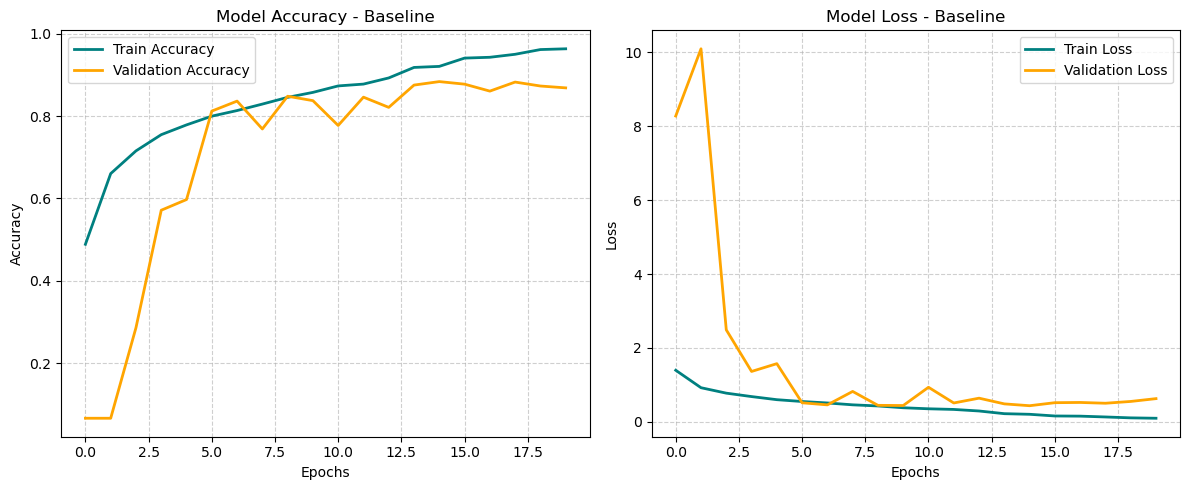

In [58]:
plot_training_history(history_baseline, experiment_name="Baseline")

# Test set

Evaluating model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.95      0.97      0.96       300
       donut       0.92      0.80      0.85        55
    edge-loc       0.84      0.86      0.85       300
   edge-ring       0.97      0.97      0.97       300
         loc       0.80      0.74      0.77       300
   near-full       1.00      0.93      0.97        15
        none       0.79      0.89      0.84       300
      random       0.90      0.95      0.93        87
     scratch       0.77      0.58      0.66       120

    accuracy                           0.87      1777
   macro avg       0.88      0.86      0.87      1777
weighted avg       0.87      0.87      0.87      1777

Plotting Confusion Matrix...


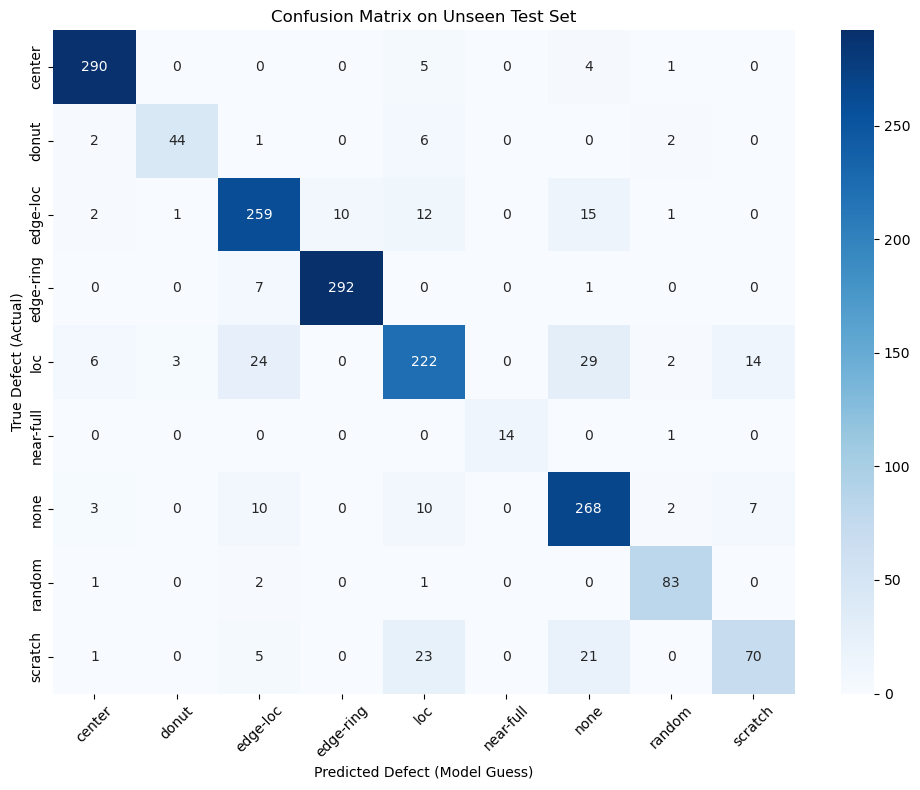

In [59]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_baseline.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiment 1: Only He Initialization

In [60]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_exp1 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer='adam'
)

# Define Callbacks with a RECOGNIZABLE file name
callbacks_exp1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Explicit and recognizable filename for this specific experiment
    ModelCheckpoint(filepath='exp1_he_initialization.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train the model
print("\nStarting training for Experiment 1...")
history_exp1 = model_exp1.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp1,
    verbose=1
)

-> Applying He Initialization

Starting training for Experiment 1...
Epoch 1/50
223/223 [==============================] - ETA: 0s - loss: 1.4773 - accuracy: 0.4711
Epoch 1: val_accuracy improved from -inf to 0.00845, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 9ms/step - loss: 1.4773 - accuracy: 0.4711 - val_loss: 31.0247 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
217/223 [============================>.] - ETA: 0s - loss: 0.9895 - accuracy: 0.6272
Epoch 2: val_accuracy did not improve from 0.00845
223/223 [==============================] - 2s 8ms/step - loss: 0.9877 - accuracy: 0.6288 - val_loss: 18.4910 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 3/50
223/223 [==============================] - ETA: 0s - loss: 0.8566 - accuracy: 0.6822
Epoch 3: val_accuracy improved from 0.00845 to 0.64921, saving model to exp1_he_initialization.h5
223/223 [==============================] - 2s 8ms/step - loss: 0.8566 - accuracy: 0.6822 - val_loss: 0.9322 -

Plotting learning curves for Exp 1 (He Init)...


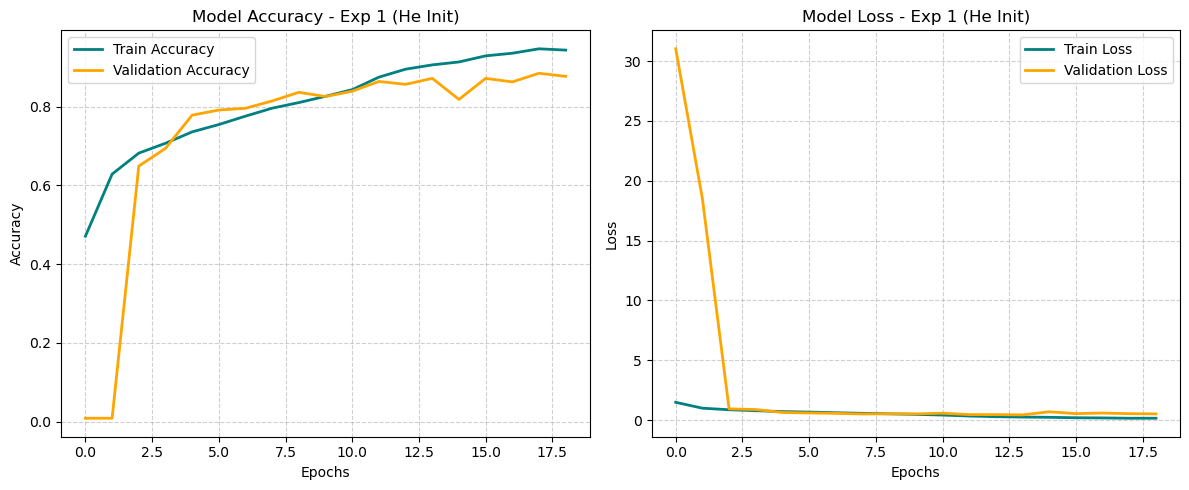

In [61]:
plot_training_history(history_exp1, experiment_name="Exp 1 (He Init)")

# Testing

Evaluating model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      center       0.95      0.94      0.95       300
       donut       0.92      0.84      0.88        55
    edge-loc       0.81      0.88      0.85       300
   edge-ring       0.98      0.97      0.97       300
         loc       0.81      0.76      0.78       300
   near-full       0.88      1.00      0.94        15
        none       0.85      0.87      0.86       300
      random       0.90      0.92      0.91        87
     scratch       0.72      0.65      0.68       120

    accuracy                           0.87      1777
   macro avg       0.87      0.87      0.87      1777
weighted avg       0.87      0.87      0.87      1777

Plotting Confusion Matrix...


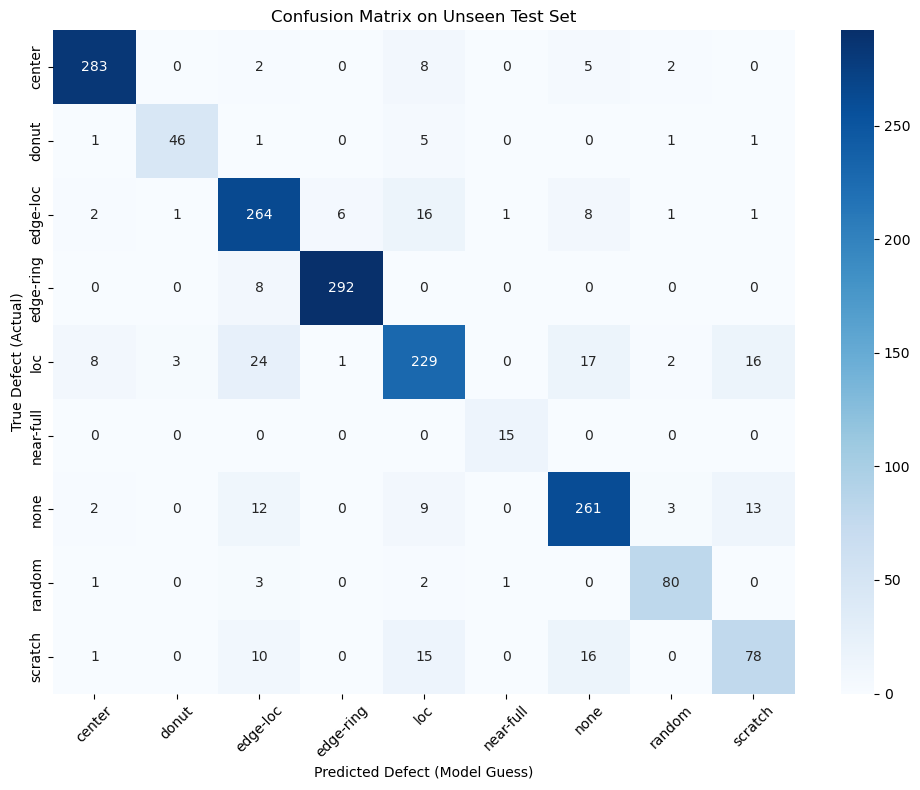

In [62]:
# 1. Get model predictions on the unseen Test Set
print("Evaluating model on Test Set...")
y_pred_probs = model_exp1.predict(X_test)

# Convert probability arrays back to class integers 
# (e.g., [0.1, 0.8, 0.1, ...] becomes class index 1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
# We retrieve the actual text names of the defects from our encoder
class_names = encoder.classes_

print("\n--- Classification Report ---")
# This will show Precision, Recall, and F1-Score for each specific defect
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
# We use a heatmap to visually highlight where the model makes mistakes
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Unseen Test Set')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 2: He Initialization + Data Augmentation

In [63]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_exp2 = build_optimized_model(
    use_he=True, 
    use_l2=False, 
    optimizer='adam'
)

# 2. Create the "CPU Factory" for Data Augmentation
print("Setting up the ImageDataGenerator...")
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72  # Randomly rotates the image up to 72 degrees
)

# 3. Define Callbacks
callbacks_exp2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Save this specific experiment's weights
    ModelCheckpoint(filepath='exp2_he_and_aug.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the generator
print("\nStarting training for Experiment 2...")
history_exp2 = model_exp2.fit(
    # We feed the generator which produces augmented batches on-the-fly
    datagen.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    # Validation data is NEVER augmented, we test on clean real data
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp2,
    verbose=1
)

-> Applying He Initialization
Setting up the ImageDataGenerator...

Starting training for Experiment 2...
Epoch 1/50
221/223 [============================>.] - ETA: 0s - loss: 1.4881 - accuracy: 0.4723
Epoch 1: val_accuracy improved from -inf to 0.00845, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 5s 22ms/step - loss: 1.4869 - accuracy: 0.4725 - val_loss: 19.7644 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
223/223 [==============================] - ETA: 0s - loss: 1.0317 - accuracy: 0.6201
Epoch 2: val_accuracy did not improve from 0.00845
223/223 [==============================] - 5s 21ms/step - loss: 1.0317 - accuracy: 0.6201 - val_loss: 7.7835 - val_accuracy: 0.0011 - lr: 0.0010
Epoch 3/50
223/223 [==============================] - ETA: 0s - loss: 0.9007 - accuracy: 0.6689
Epoch 3: val_accuracy improved from 0.00845 to 0.58221, saving model to exp2_he_and_aug.h5
223/223 [==============================] - 5s 21ms/step - loss: 0.9007 - accuracy: 0.

Plotting learning curves for Exp 2 (He Init + Data Augmentation)...


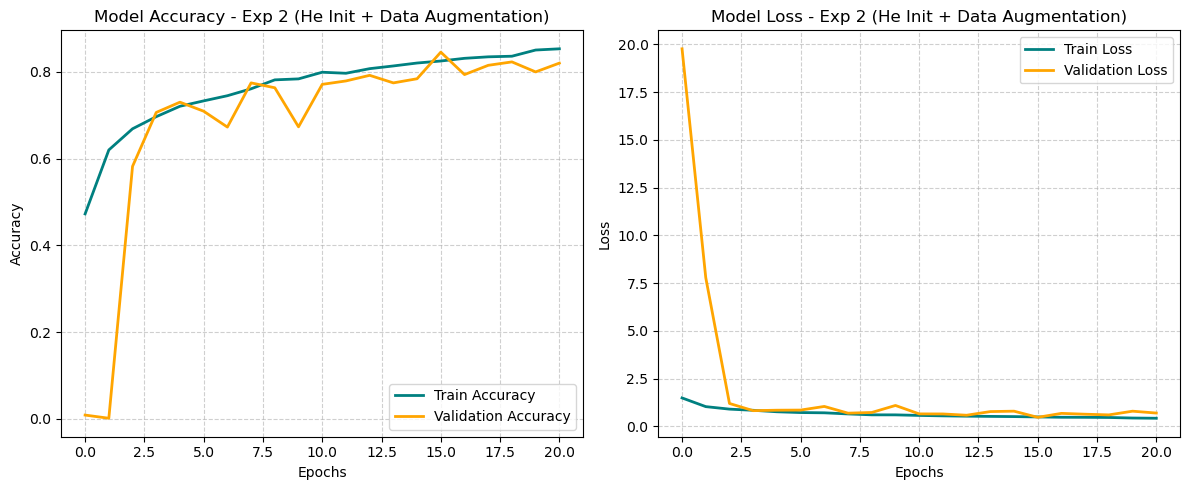

In [64]:
plot_training_history(history_exp2, experiment_name="Exp 2 (He Init + Data Augmentation)")

Evaluating Exp 2 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 2) ---
              precision    recall  f1-score   support

      center       0.93      0.94      0.94       300
       donut       0.93      0.73      0.82        55
    edge-loc       0.75      0.84      0.79       300
   edge-ring       0.89      0.98      0.93       300
         loc       0.79      0.64      0.71       300
   near-full       0.68      1.00      0.81        15
        none       0.80      0.87      0.83       300
      random       0.75      0.91      0.82        87
     scratch       0.76      0.43      0.55       120

    accuracy                           0.82      1777
   macro avg       0.81      0.81      0.80      1777
weighted avg       0.82      0.82      0.82      1777

Plotting Confusion Matrix...


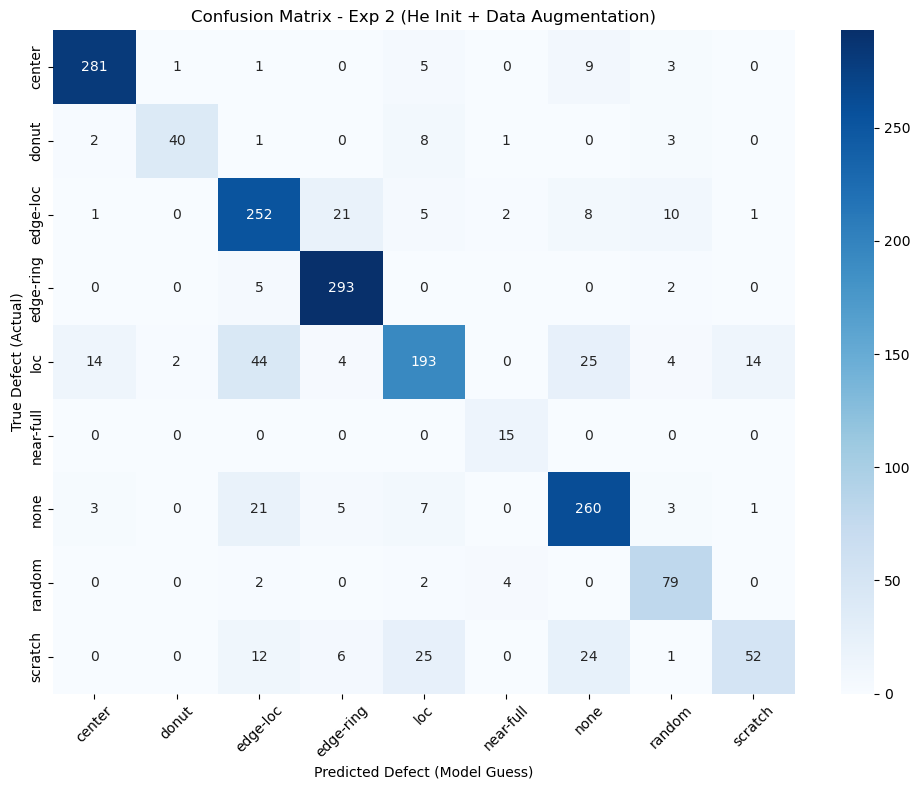

In [65]:
# 1. Get model predictions using the SPECIFIC model from Experiment 2
print("Evaluating Exp 2 model on Test Set...")
y_pred_probs_exp2 = model_exp2.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp2 = np.argmax(y_pred_probs_exp2, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 2) ---")
print(classification_report(y_true_classes, y_pred_classes_exp2, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp2 = confusion_matrix(y_true_classes, y_pred_classes_exp2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp2, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 2 (He Init + Data Augmentation)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Safe Augmentation

In [66]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_confirm = build_optimized_model(
    use_he=True, 
    use_l2=False, # Teniamo L2 spento per isolare l'effetto della sola Augmentation
    optimizer='adam'
)

# Safe Augmentation
datagen_safe = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
)

# Training
history_confirm = model_confirm.fit(
    datagen_safe.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    validation_data=(X_val, y_val_categorical),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),  # ← aggiungere
        ModelCheckpoint(filepath='confirm_safe_aug.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ],
    verbose=1
)

-> Applying He Initialization
Epoch 1/50
221/223 [============================>.] - ETA: 0s - loss: 1.3709 - accuracy: 0.5290
Epoch 1: val_accuracy improved from -inf to 0.00845, saving model to confirm_safe_aug.h5
223/223 [==============================] - 3s 10ms/step - loss: 1.3680 - accuracy: 0.5299 - val_loss: 25.7885 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
222/223 [============================>.] - ETA: 0s - loss: 0.9383 - accuracy: 0.6579
Epoch 2: val_accuracy improved from 0.00845 to 0.02928, saving model to confirm_safe_aug.h5
223/223 [==============================] - 2s 9ms/step - loss: 0.9382 - accuracy: 0.6577 - val_loss: 6.3935 - val_accuracy: 0.0293 - lr: 0.0010
Epoch 3/50
219/223 [============================>.] - ETA: 0s - loss: 0.8294 - accuracy: 0.7009
Epoch 3: val_accuracy improved from 0.02928 to 0.73029, saving model to confirm_safe_aug.h5
223/223 [==============================] - 2s 9ms/step - loss: 0.8288 - accuracy: 0.7014 - val_loss: 0.7390 - val_accur

Plotting learning curves for Confirmation (He Init + Safe Augmentation)...


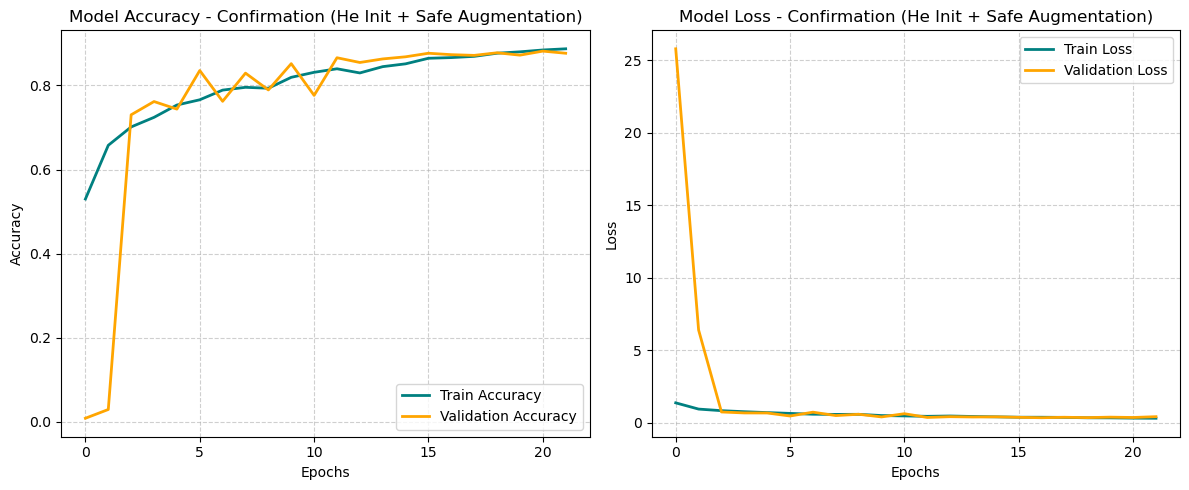

In [67]:
plot_training_history(history_confirm, experiment_name="Confirmation (He Init + Safe Augmentation)")

56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 2) ---
              precision    recall  f1-score   support

      center       0.94      0.96      0.95       300
       donut       0.84      0.87      0.86        55
    edge-loc       0.86      0.87      0.87       300
   edge-ring       0.97      0.97      0.97       300
         loc       0.75      0.78      0.77       300
   near-full       0.93      0.93      0.93        15
        none       0.86      0.89      0.88       300
      random       0.88      0.92      0.90        87
     scratch       0.73      0.55      0.63       120

    accuracy                           0.87      1777
   macro avg       0.87      0.86      0.86      1777
weighted avg       0.87      0.87      0.87      1777

Plotting Confusion Matrix...


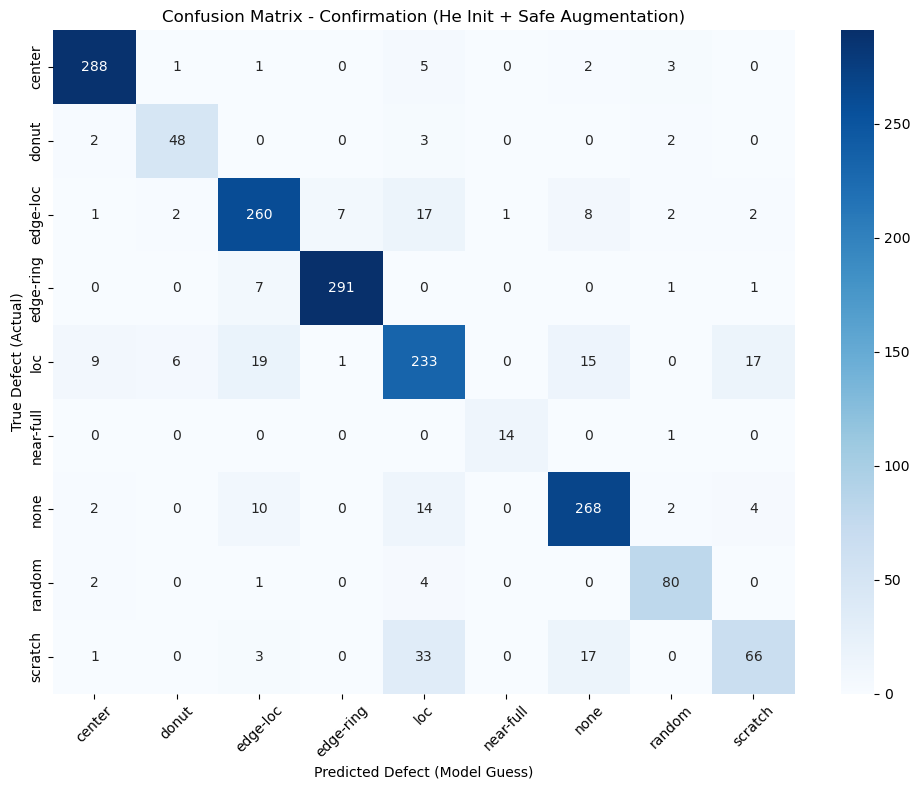

In [68]:
y_pred_probs_conf = model_confirm.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_conf = np.argmax(y_pred_probs_conf, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 2) ---")
print(classification_report(y_true_classes, y_pred_classes_conf, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_conf = confusion_matrix(y_true_classes, y_pred_classes_conf)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_conf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Confirmation (He Init + Safe Augmentation)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EXPERIMENT 3: He Init + Safe Flips + L2 Regularization

In [69]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_exp3 = build_optimized_model(
    use_he=True, 
    use_l2=True,
    optimizer='adam'
)

# 2. Create the "Safe CPU Factory" for Data Augmentation
print("Setting up the safe ImageDataGenerator...")
datagen_safe = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
    # Rimosso rotation_range per evitare che l'interpolazione cancelli i graffi!
)

# 3. Define Callbacks
callbacks_exp3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='exp3_safe_aug_l2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 4. Train the model using the SAFE generator
print("\nStarting training for Experiment 3...")
history_exp3 = model_exp3.fit(
    datagen_safe.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
    epochs=50,
    validation_data=(X_val, y_val_categorical),
    callbacks=callbacks_exp3,
    verbose=1
)

-> Applying He Initialization
-> Applying L2 Regularization
Setting up the safe ImageDataGenerator...

Starting training for Experiment 3...
Epoch 1/50
218/223 [============================>.] - ETA: 0s - loss: 2.0485 - accuracy: 0.5243
Epoch 1: val_accuracy improved from -inf to 0.00845, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 3s 11ms/step - loss: 2.0389 - accuracy: 0.5270 - val_loss: 22.7751 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
218/223 [============================>.] - ETA: 0s - loss: 1.4708 - accuracy: 0.6654
Epoch 2: val_accuracy improved from 0.00845 to 0.02928, saving model to exp3_safe_aug_l2.h5
223/223 [==============================] - 2s 10ms/step - loss: 1.4674 - accuracy: 0.6662 - val_loss: 6.1356 - val_accuracy: 0.0293 - lr: 0.0010
Epoch 3/50
218/223 [============================>.] - ETA: 0s - loss: 1.2996 - accuracy: 0.7037
Epoch 3: val_accuracy improved from 0.02928 to 0.23367, saving model to exp3_safe_aug_l2.h5
223/223

Plotting learning curves for Exp 3 (He Init + Safe Aug + L2)...


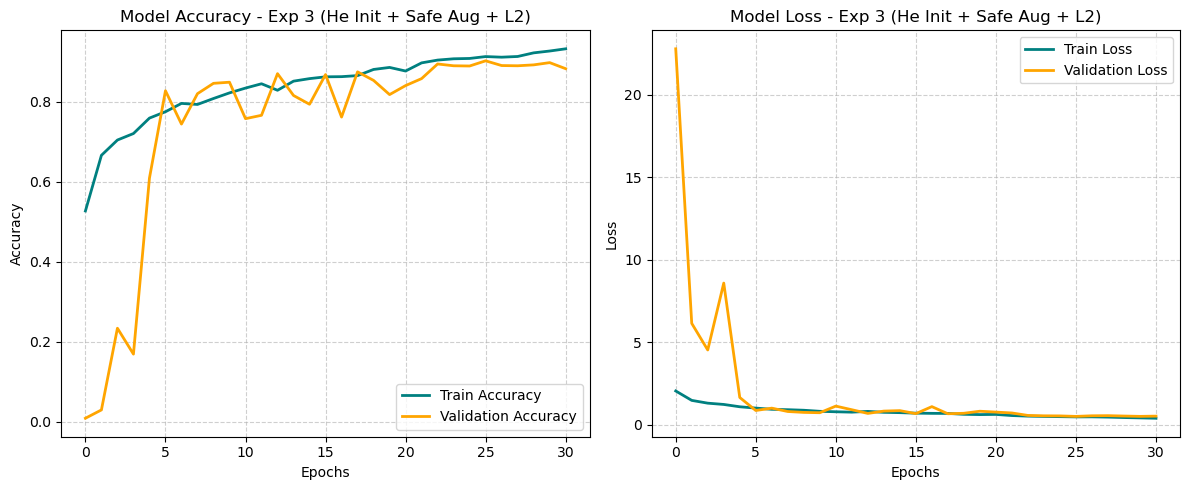

In [70]:
# Execute the plotting function using the history from Experiment 3
plot_training_history(history_exp3, experiment_name="Exp 3 (He Init + Safe Aug + L2)")

Evaluating Exp 3 model on Test Set...
56/56 [==============================] - 0s 2ms/step

--- Classification Report (Exp 3) ---
              precision    recall  f1-score   support

      center       0.96      0.96      0.96       300
       donut       0.85      0.80      0.82        55
    edge-loc       0.89      0.84      0.87       300
   edge-ring       0.95      1.00      0.98       300
         loc       0.84      0.77      0.80       300
   near-full       0.94      1.00      0.97        15
        none       0.89      0.92      0.91       300
      random       0.89      0.93      0.91        87
     scratch       0.81      0.90      0.85       120

    accuracy                           0.90      1777
   macro avg       0.89      0.90      0.90      1777
weighted avg       0.90      0.90      0.90      1777

Plotting Confusion Matrix...


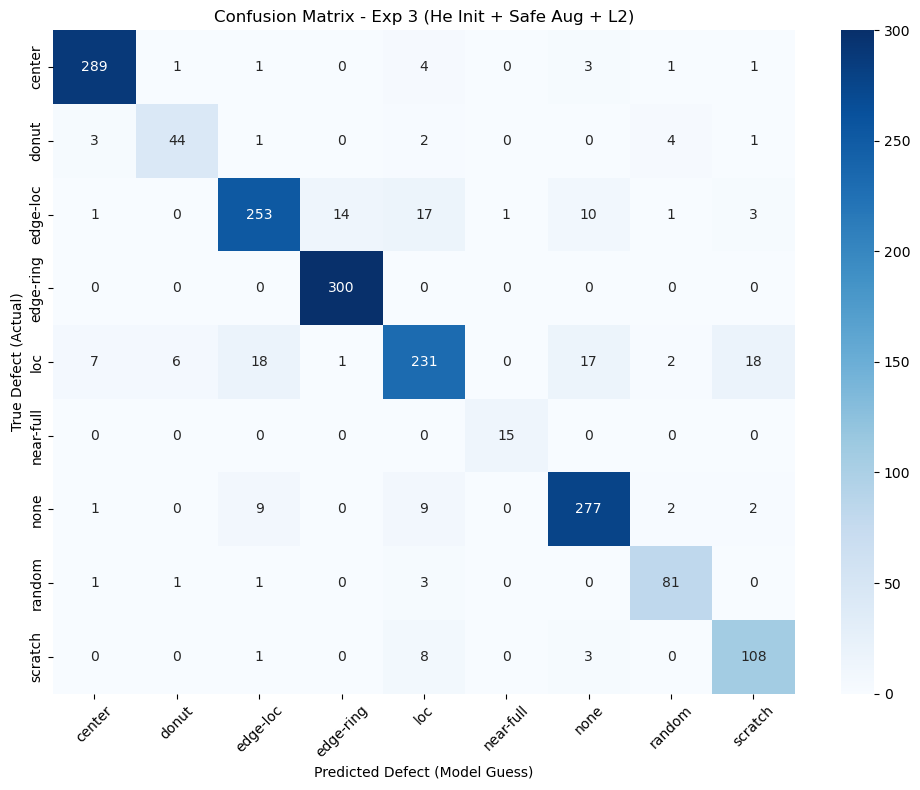

In [71]:
# 1. Get model predictions using the SPECIFIC model from Experiment 3
print("Evaluating Exp 3 model on Test Set...")
y_pred_probs_exp3 = model_exp3.predict(X_test)

# Convert probability arrays back to class integers 
y_pred_classes_exp3 = np.argmax(y_pred_probs_exp3, axis=1)
y_true_classes = np.argmax(y_test_categorical, axis=1)

# 2. Generate the Classification Report
class_names = encoder.classes_

print("\n--- Classification Report (Exp 3) ---")
print(classification_report(y_true_classes, y_pred_classes_exp3, target_names=class_names))

# 3. Plot the Confusion Matrix
print("Plotting Confusion Matrix...")
cm_exp3 = confusion_matrix(y_true_classes, y_pred_classes_exp3)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_exp3, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Exp 3 (He Init + Safe Aug + L2)')
plt.ylabel('True Defect (Actual)')
plt.xlabel('Predicted Defect (Model Guess)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
print("--- FINAL MODEL COMPARISON ---")

# 1. Configurazione modelli per il caricamento dei pesi
models_config = {
    "Baseline CNN": {"file": "baseline.h5", "he": False, "l2": False},
    "Exp 1 (He Init)": {"file": "exp1_he_initialization.h5", "he": True, "l2": False},
    "Exp 2 (Bad Aug)": {"file": "exp2_he_and_aug.h5", "he": True, "l2": False},
    "Confirmation Exp": {"file": "confirm_safe_aug.h5", "he": True, "l2": False},
    "Exp 3 (Safe Aug + L2)": {"file": "exp3_safe_aug_l2.h5", "he": True, "l2": True}
}

models_dict = {}
y_true = np.argmax(y_test_categorical, axis=1)
results_list = []
cm_dict = {}

# 2. Caricamento e Valutazione
for name, config in models_config.items():
    print(f"Loading and evaluating {name}...")
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    model = build_optimized_model(use_he=config["he"], use_l2=config["l2"])
    model.load_weights(config["file"])
    models_dict[name] = model
    
    # Previsioni
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Metriche
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred) # Nuova metrica aggiunta
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    
    results_list.append({
        "Model": name, 
        "Accuracy": round(acc * 100, 2), 
        "Balanced Accuracy": round(bal_acc * 100, 2), 
        "F1-Score": round(f1 * 100, 2)
    })
    cm_dict[name] = confusion_matrix(y_true, y_pred)

# 3. Tabella Risultati
benchmark_df = pd.DataFrame(results_list).set_index("Model")
display(benchmark_df)

--- FINAL MODEL COMPARISON ---
Loading and evaluating Baseline CNN...
Loading and evaluating Exp 1 (He Init)...
-> Applying He Initialization
Loading and evaluating Exp 2 (Bad Aug)...
-> Applying He Initialization
Loading and evaluating Confirmation Exp...
-> Applying He Initialization
Loading and evaluating Exp 3 (Safe Aug + L2)...
-> Applying He Initialization
-> Applying L2 Regularization


,Accuracy,Balanced Accuracy,F1-Score
Model,,,
Baseline CNN,86.78,85.64,86.65
Exp 1 (He Init),88.01,86.73,87.34
Exp 2 (Bad Aug),82.44,81.47,79.99
Confirmation Exp,88.07,86.01,87.19
Exp 3 (Safe Aug + L2),89.93,90.34,89.66


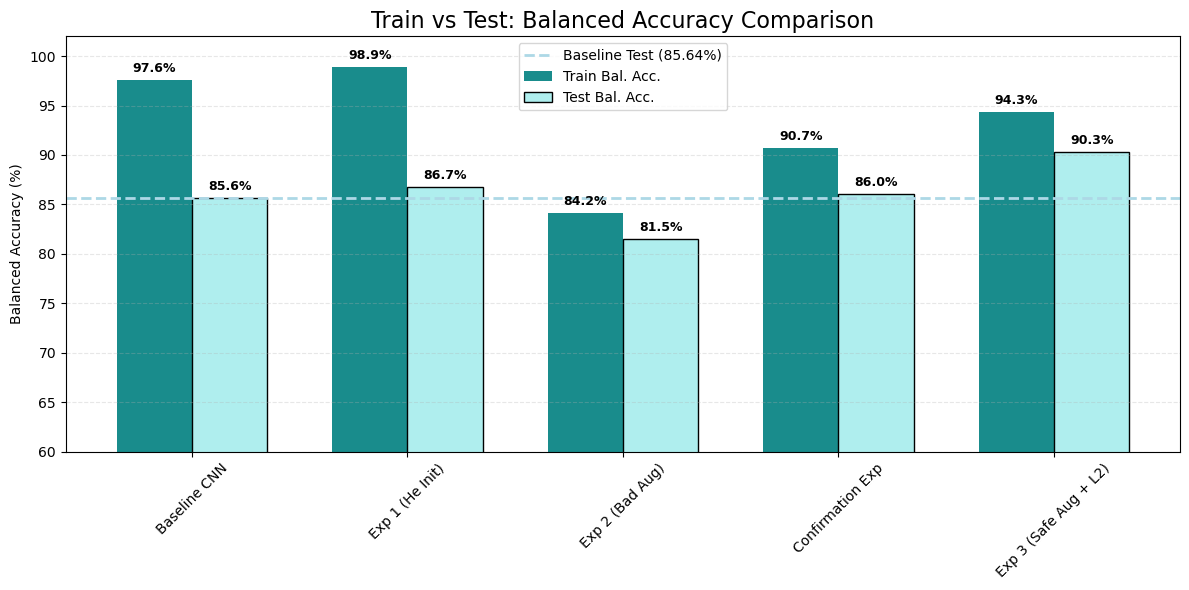

In [81]:
train_scores = []
test_scores = []
model_names = list(models_dict.keys())

for name in model_names:
    model = models_dict[name]
    
    # Valutazione Train
    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_train_true = np.argmax(y_train_categorical, axis=1)
    train_scores.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)
    
    # Valutazione Test
    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_scores.append(balanced_accuracy_score(y_true, y_test_pred) * 100)

# 2. Setup grafico a doppia barra
x = np.arange(len(model_names))
width = 0.35 

plt.figure(figsize=(12, 6))

# Barre chiare (Test) e scure (Train)
rects1 = plt.bar(x - width/2, train_scores, width, label='Train Bal. Acc.', color='teal', alpha=0.9)
rects2 = plt.bar(x + width/2, test_scores, width, label='Test Bal. Acc.', color='paleturquoise', edgecolor='black')

# Linea Baseline (usa il valore di Test della Baseline)
plt.axhline(y=test_scores[0], color='lightblue', linestyle='--', linewidth=2, label=f'Baseline Test ({test_scores[0]:.2f}%)')

# 3. Formattazione
plt.ylim(60, 102)
plt.ylabel('Balanced Accuracy (%)')
plt.title('Train vs Test: Balanced Accuracy Comparison', fontsize=16)
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()

In [74]:
# Safe augmentation — same as Exp 3
datagen_best = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True
)

OPTIMIZER_REGISTRY = {
    "Adam":           lambda: Adam(learning_rate=0.001),
    "SGD + Nesterov": lambda: SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "RMSprop":        lambda: RMSprop(learning_rate=0.001),
    "Nadam":          lambda: Nadam(learning_rate=0.001),
}

WEIGHT_FILES_BEST = {
    "Adam":           "best_adam.h5",
    "SGD + Nesterov": "best_sgd_nesterov.h5",
    "RMSprop":        "best_rmsprop.h5",
    "Nadam":          "best_nadam.h5",
}

histories_best = {}
models_best = {}

for opt_name, build_opt in OPTIMIZER_REGISTRY.items():
    print(f"\n{'='*55}")
    print(f"  Training Best Model with: {opt_name}")
    print(f"{'='*55}")

    # Same seed reset as before for fair initialization comparison
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    
    model = build_optimized_model(use_he=True, use_l2=True, optimizer=build_opt())

    history = model.fit(
        datagen_best.flow(X_train, y_train_categorical, batch_size=64, seed=SEED),
        epochs=50,
        validation_data=(X_val, y_val_categorical),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=3, min_lr=1e-6, verbose=1),
            ModelCheckpoint(filepath=WEIGHT_FILES_BEST[opt_name],
                            monitor='val_accuracy',
                            save_best_only=True, verbose=0),
        ],
        verbose=1,
    )

    histories_best[opt_name] = history
    models_best[opt_name]    = model
    print(f"{opt_name} done")


  Training Best Model with: Adam
-> Applying He Initialization
-> Applying L2 Regularization
Epoch 1/50
223/223 [==============================] - 3s 11ms/step - loss: 2.0389 - accuracy: 0.5270 - val_loss: 22.7751 - val_accuracy: 0.0084 - lr: 0.0010
Epoch 2/50
223/223 [==============================] - 2s 10ms/step - loss: 1.4674 - accuracy: 0.6662 - val_loss: 6.1356 - val_accuracy: 0.0293 - lr: 0.0010
Epoch 3/50
223/223 [==============================] - 2s 10ms/step - loss: 1.2992 - accuracy: 0.7044 - val_loss: 4.5220 - val_accuracy: 0.2337 - lr: 0.0010
Epoch 4/50
223/223 [==============================] - 2s 9ms/step - loss: 1.2211 - accuracy: 0.7207 - val_loss: 8.5767 - val_accuracy: 0.1689 - lr: 0.0010
Epoch 5/50
223/223 [==============================] - 2s 9ms/step - loss: 1.0807 - accuracy: 0.7593 - val_loss: 1.6433 - val_accuracy: 0.6092 - lr: 0.0010
Epoch 6/50
223/223 [==============================] - 2s 10ms/step - loss: 1.0006 - accuracy: 0.7752 - val_loss: 0.8551 - val_a

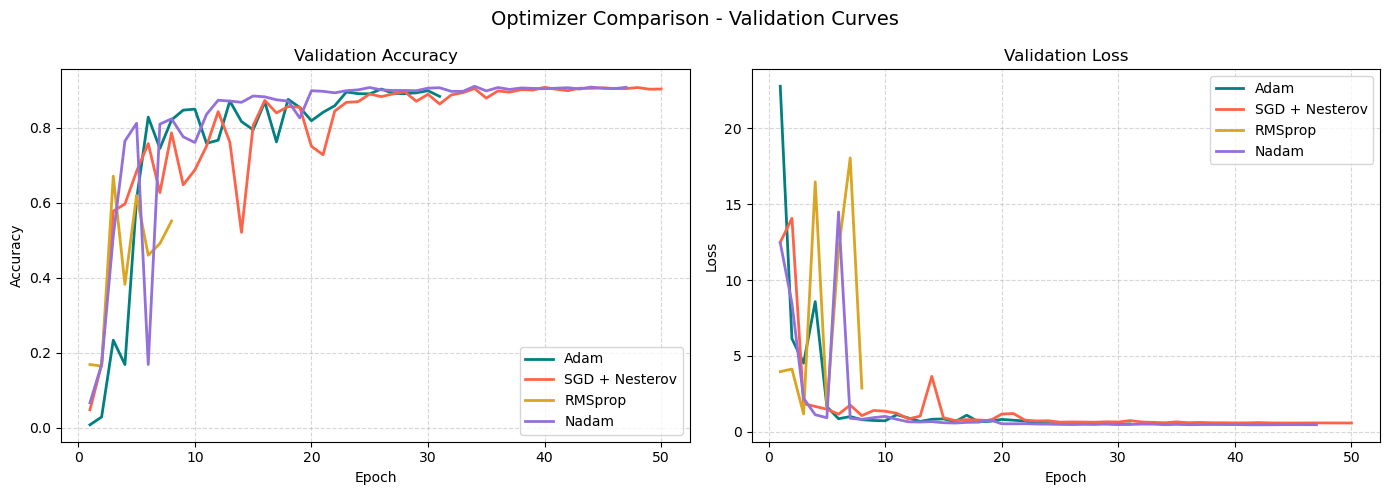

In [75]:
COLORS = ["teal", "tomato", "goldenrod", "mediumpurple"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimizer Comparison - Validation Curves", fontsize=14)

for (opt_name, history), color in zip(histories_best.items(), COLORS):
    epochs_range = range(1, len(history.history['val_accuracy']) + 1)

    axes[0].plot(epochs_range, history.history['val_accuracy'],
                 label=opt_name, color=color, linewidth=2)
    axes[1].plot(epochs_range, history.history['val_loss'],
                 label=opt_name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
                               ["Validation Accuracy", "Validation Loss"],
                               ["Accuracy", "Loss"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

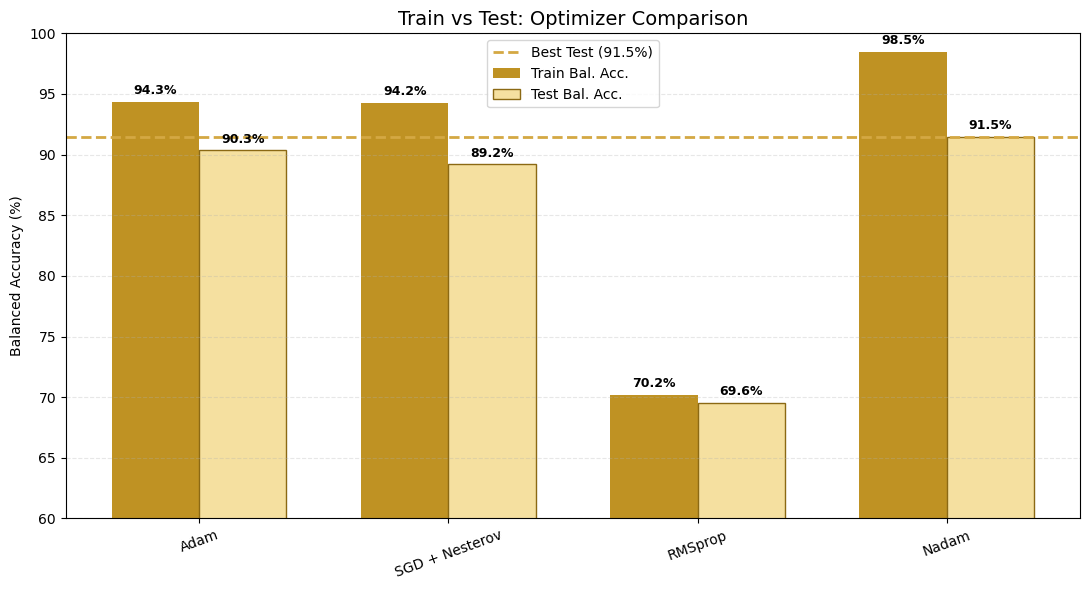

In [76]:
opt_names    = list(models_best.keys())
train_scores = []
test_scores  = []

y_train_true = np.argmax(y_train_categorical, axis=1)
y_test_true  = np.argmax(y_test_categorical,  axis=1)

for opt_name in opt_names:
    model = models_best[opt_name]

    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    train_scores.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)

    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_scores.append(balanced_accuracy_score(y_test_true, y_test_pred) * 100)

# Plot 
x     = np.arange(len(opt_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_train = ax.bar(x - width / 2, train_scores, width,
                    label='Train Bal. Acc.',
                    color='#B8860B', alpha=0.9)          # dark goldenrod

bars_test  = ax.bar(x + width / 2, test_scores, width,
                    label='Test Bal. Acc.',
                    color='#F5E0A0', edgecolor='#8B6914') # pale ochre + dark border

best_test = max(test_scores)
ax.axhline(y=best_test, color='#D4A843', linestyle='--', linewidth=2,
           label=f'Best Test ({best_test:.1f}%)')          # mid ochre

add_bar_labels(ax, bars_train)
add_bar_labels(ax,bars_test)

ax.set_ylim(60, 100)
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Train vs Test: Optimizer Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(opt_names, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Bigger test set

In [77]:
# 1. Recuperiamo gli indici esatti usati per il training e validation set originali
# Utilizziamo lo stesso identico seed (42) e la stessa stratificazione del notebook
train_idx, temp_idx, _, y_temp_bal = train_test_split(
    balanced_indices, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

val_idx, test_idx, _, _ = train_test_split(
    temp_idx, y_temp_bal, test_size=0.50, random_state=42, stratify=y_temp_bal
)

# Uniamo gli indici di training e validation per escluderli ed evitare data leakage
exclude_indices = np.concatenate([train_idx, val_idx])

# 2. Creiamo l'indice per il "Test Set Completo" 
# (Tutto il dataset originale tranne i dati che il modello ha già "visto" o usato per fermarsi)
all_indices = np.arange(len(X))
complete_test_idx = np.setdiff1d(all_indices, exclude_indices)

# 3. Estraiamo i dati per il test set completo e prepariamo i tensori
X_complete_test = X[complete_test_idx]
y_complete_test = y[complete_test_idx]

print(f"Campioni usati in Train/Val: {len(exclude_indices)}")
print(f"Dimensione del Test Set Completo: {X_complete_test.shape[0]} campioni")

# 4. Normalizzazione dei pixel e OHE
print("Normalizzazione del Test Set Completo...")
X_complete_test_normalized = X_complete_test.astype('float32') / 255.0

num_classes = len(np.unique(y))
y_complete_test_categorical = to_categorical(y_complete_test, num_classes=num_classes)

Campioni usati in Train/Val: 15986
Dimensione del Test Set Completo: 156964 campioni
Normalizzazione del Test Set Completo...


In [78]:
# 1. Costruiamo il modello con la funzione ottimizzata già definita
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
model_nadam = build_optimized_model(use_he=True, use_l2=True, optimizer='nadam')

# Carichiamo i pesi
model_nadam.load_weights('best_nadam.h5')
print("Pesi best_nadam.h5 caricati con successo!")

# 2. Valutazione standard Keras
print("\nValutazione sul Test Set Completo in corso...")
loss, accuracy = model_nadam.evaluate(X_complete_test_normalized, y_complete_test_categorical, batch_size=64)

print(f"\n--- RISULTATI GENERALI ---")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# 3. Predizioni e Report Dettagliato
print("\nGenerazione delle predizioni per il Classification Report...")
y_pred_probs = model_nadam.predict(X_complete_test_normalized, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_complete_test, y_pred, target_names=encoder.classes_))

# 4. Accuratezza Bilanciata
# Fondamentale perché il "Test Set Completo" sarà pesantemente sbilanciato come l'originale
bal_acc = balanced_accuracy_score(y_complete_test, y_pred)
print(f"Balanced Accuracy (fondamentale per set sbilanciato): {bal_acc*100:.2f}%")

-> Applying He Initialization
-> Applying L2 Regularization
Pesi best_nadam.h5 caricati con successo!

Valutazione sul Test Set Completo in corso...
2453/2453 [==============================] - 13s 4ms/step - loss: 0.4178 - accuracy: 0.9305

--- RISULTATI GENERALI ---
Loss: 0.4178
Accuracy: 93.05%

Generazione delle predizioni per il Classification Report...
2453/2453 [==============================] - 10s 3ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      center       0.51      0.96      0.66      1594
       donut       0.64      0.87      0.74        55
    edge-loc       0.39      0.89      0.54      2489
   edge-ring       0.96      0.98      0.97      6980
         loc       0.15      0.82      0.25       893
   near-full       0.88      1.00      0.94        15
        none       1.00      0.93      0.96    144731
      random       0.33      0.94      0.49        87
     scratch       0.08      0.80      0.15       120

    accu

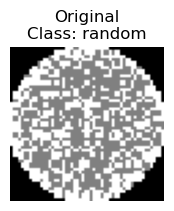

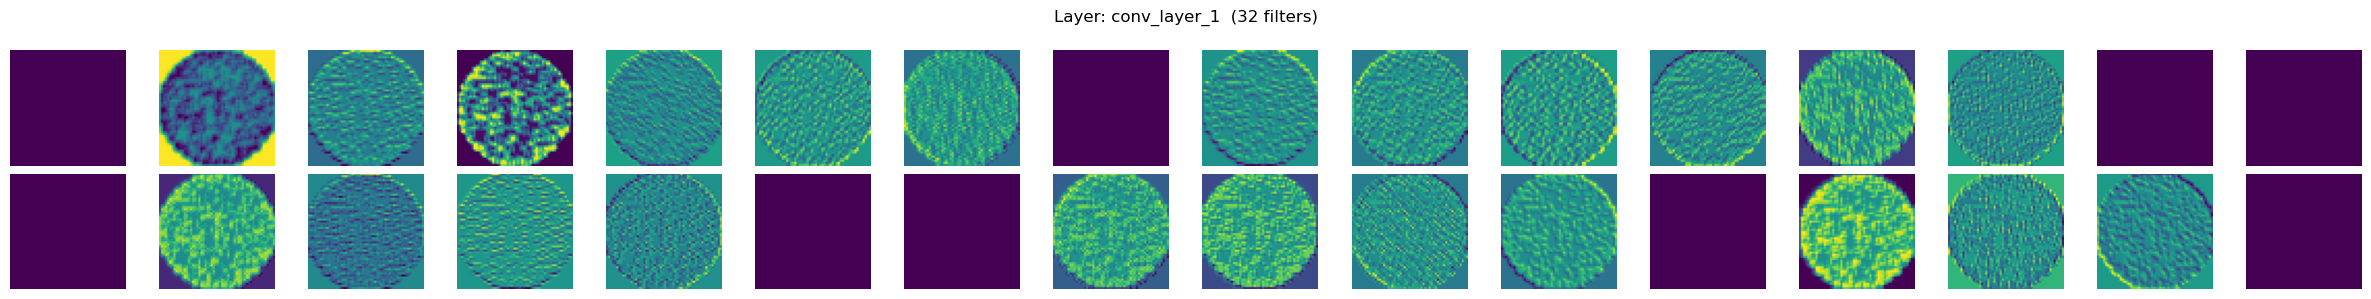

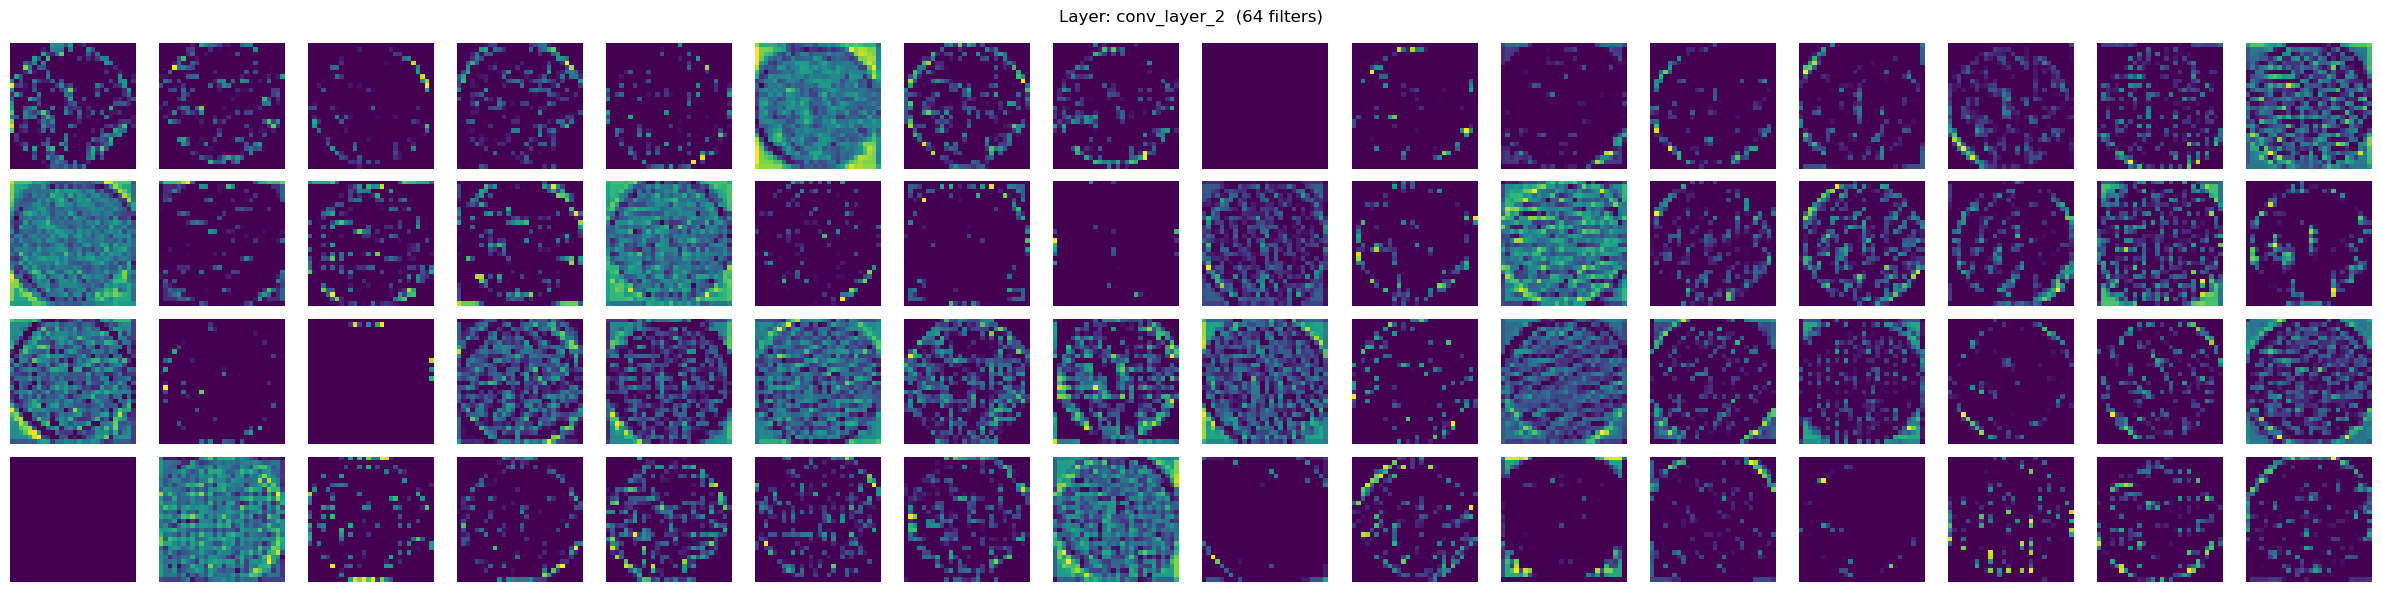

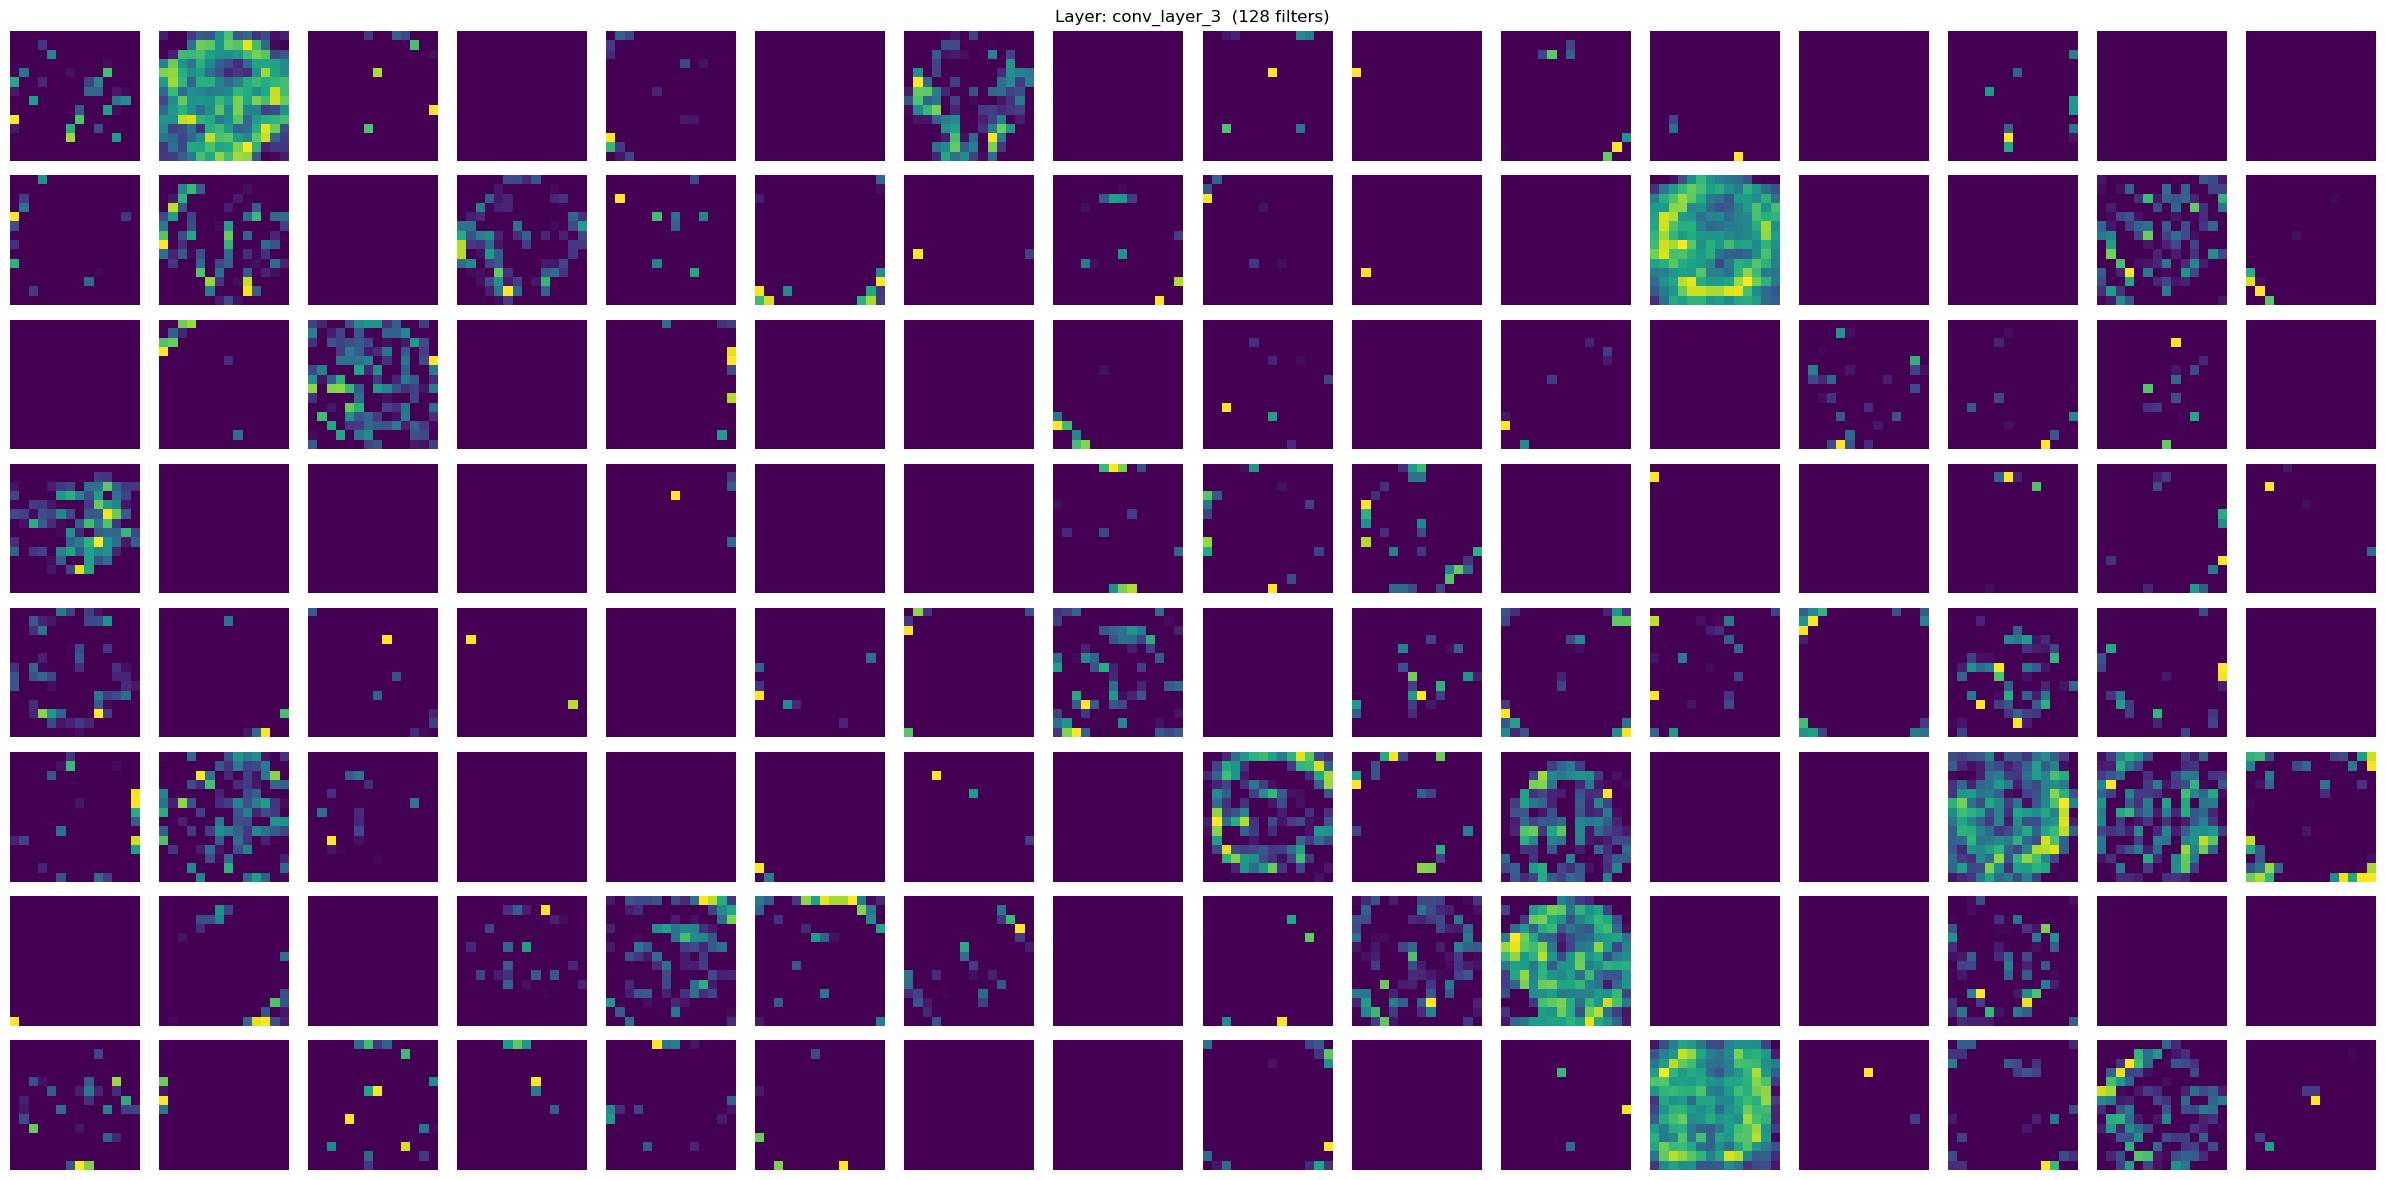

In [79]:
# Modello dal training loop dei best models
idx = 300
visualize_original_and_maps(models_best["Nadam"], X_test[idx], y_true[idx], class_names)

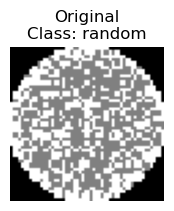

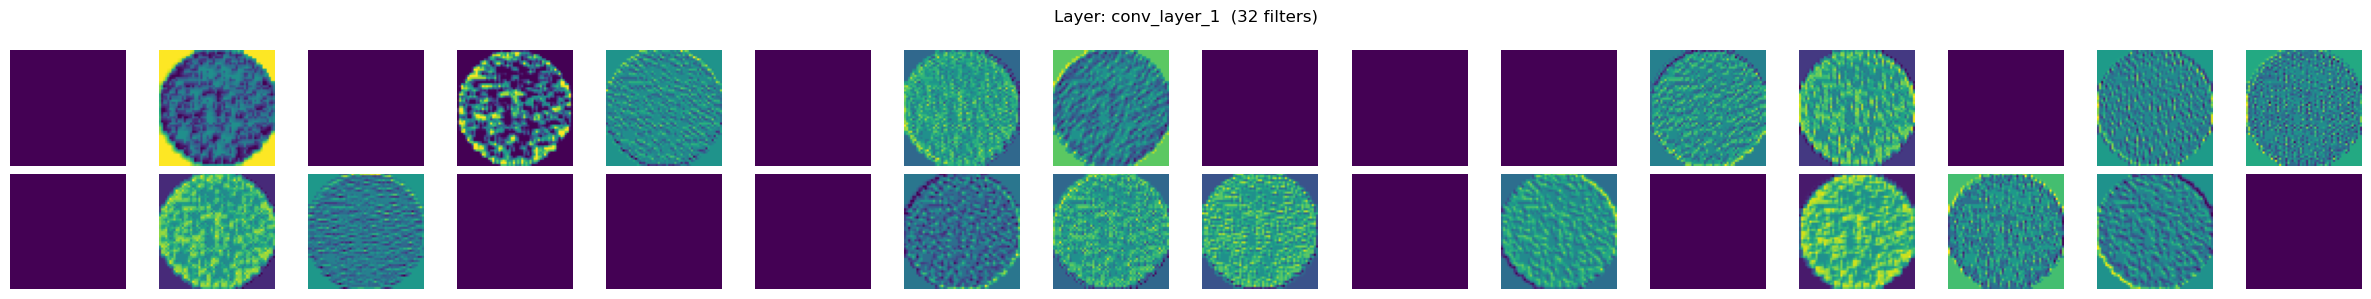

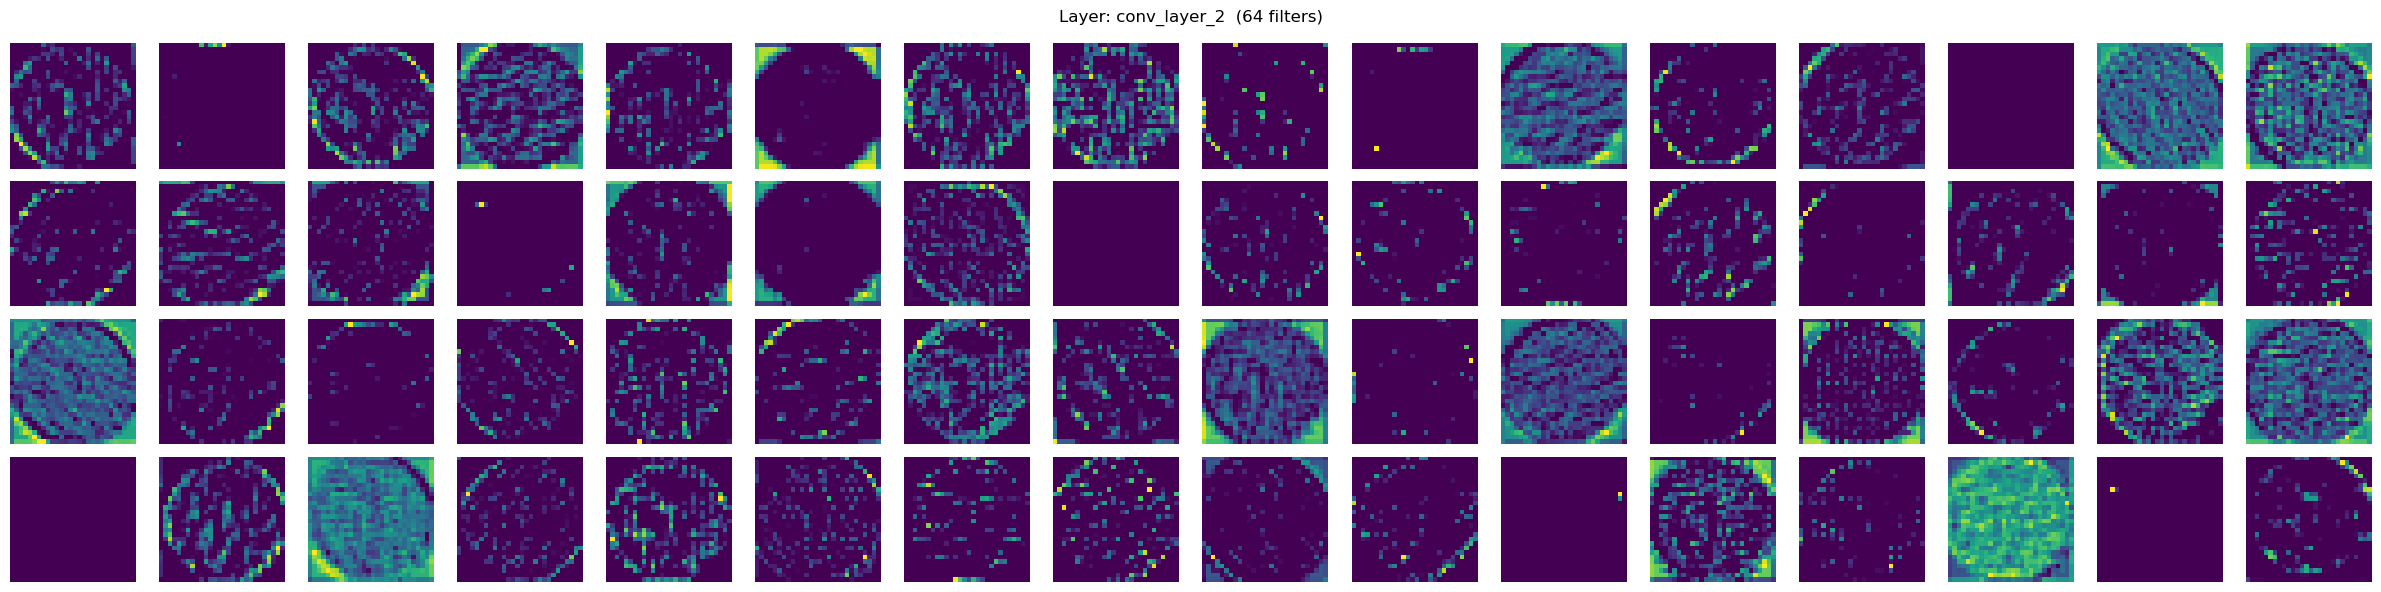

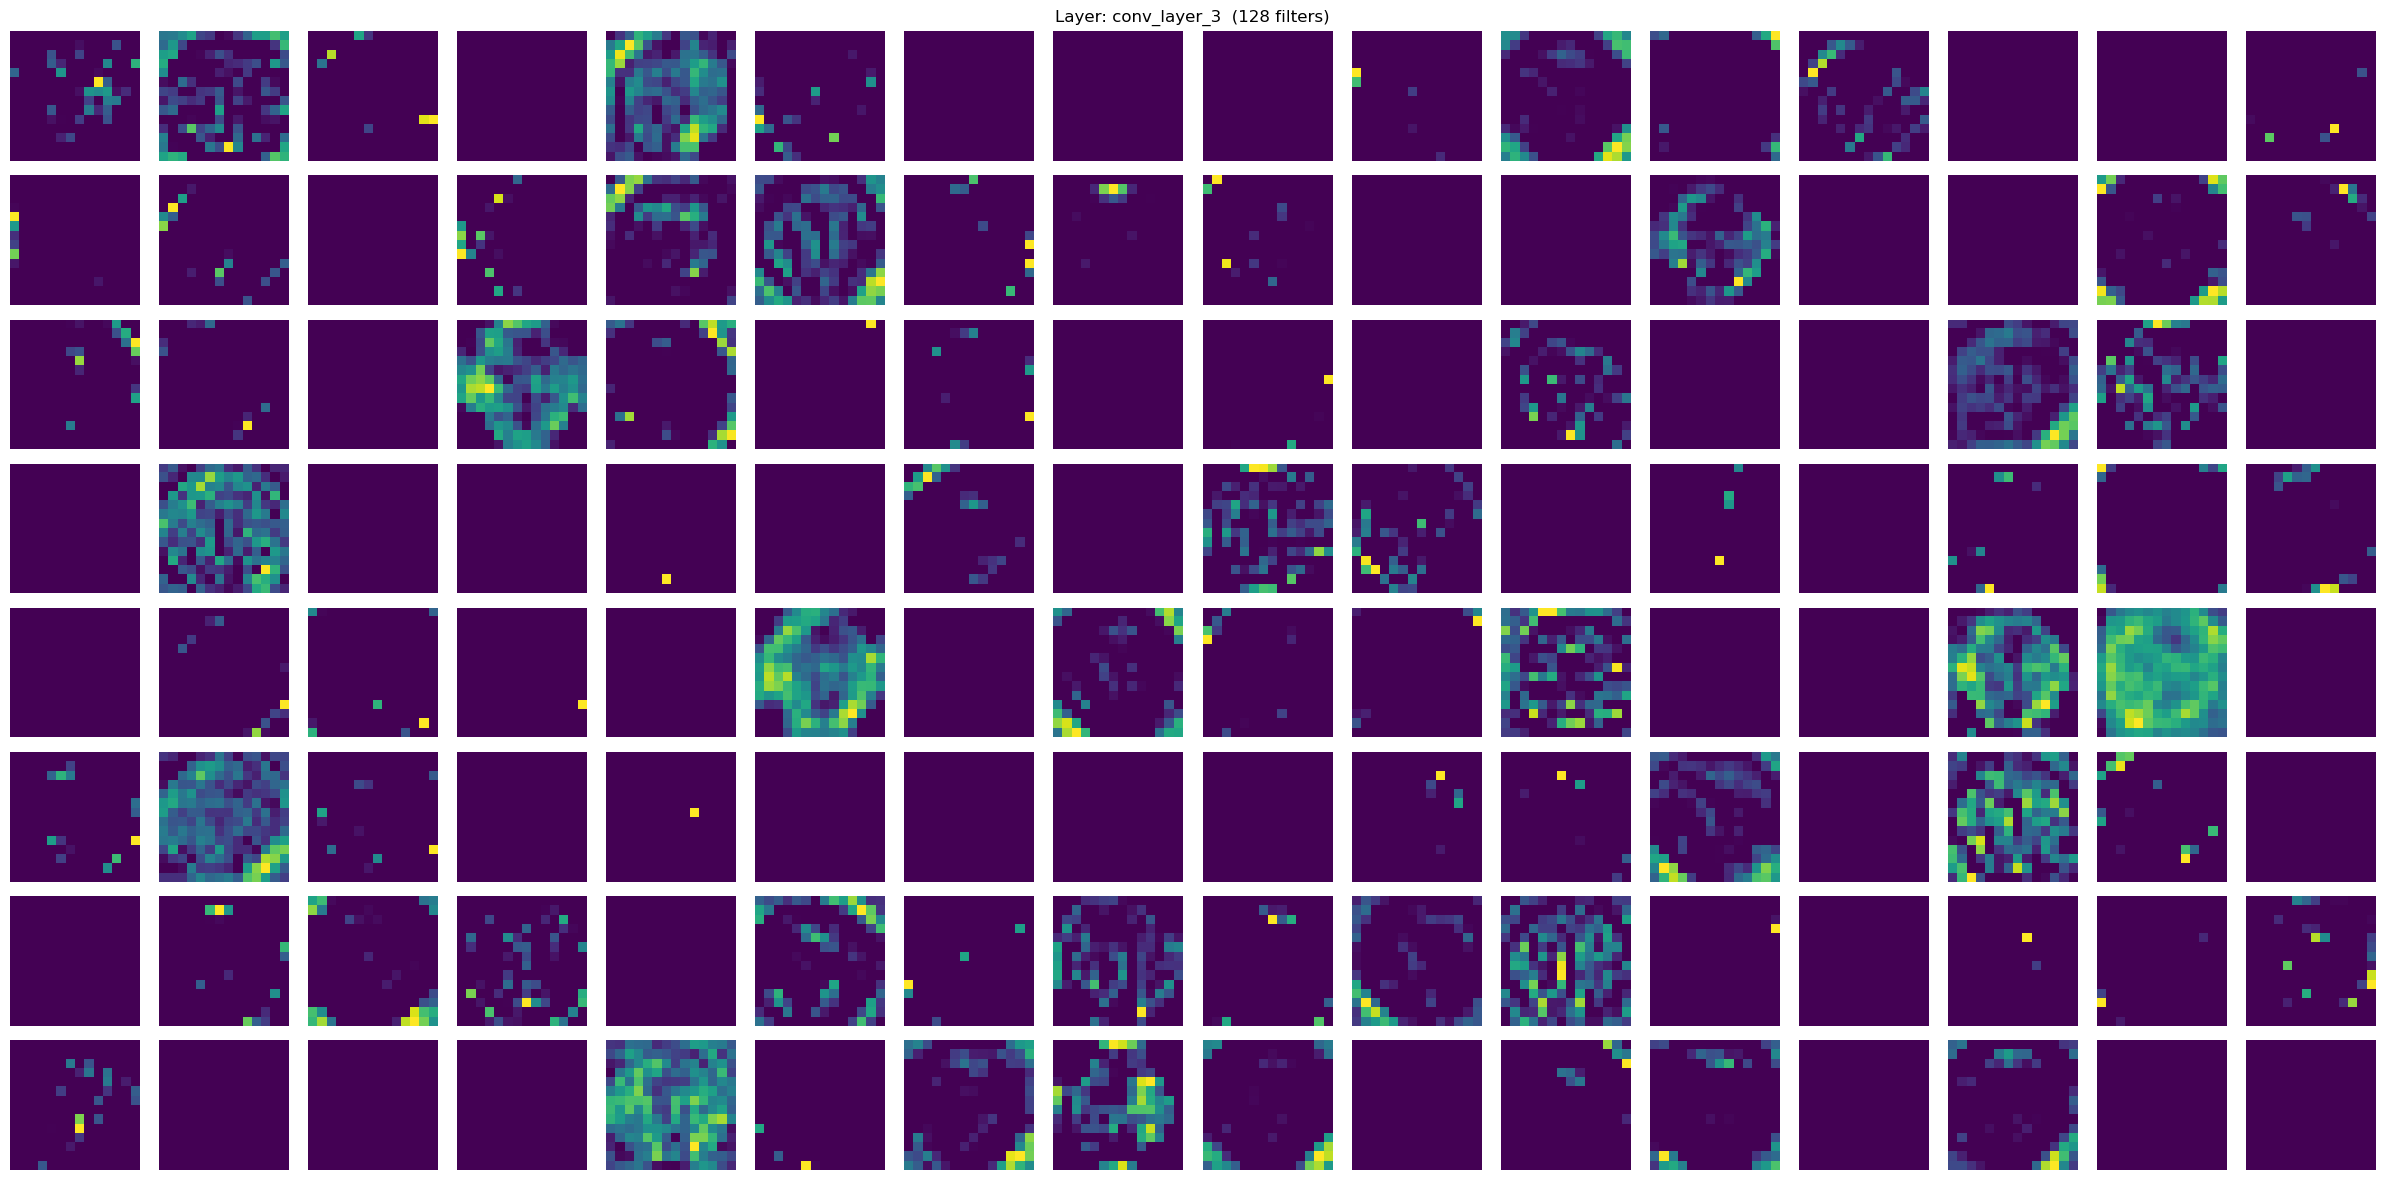

In [80]:
idx = 300
visualize_original_and_maps(models_dict['Exp 3 (Safe Aug + L2)'], X_test[idx], y_true[idx], class_names)